![Mysql](https://labs.mysql.com/common/logos/mysql-logo.svg)

# Toma de contacto con Jupyter/Colab y SQL (sesión 1)

Esta hoja muestra cómo acceder a bases de datos SQL y también a conectar la salida con Jupyter. Las partes en SQL también se pueden realizar directamente en MySQL ejecutando el programa `mysql` del entorno de ejecución.

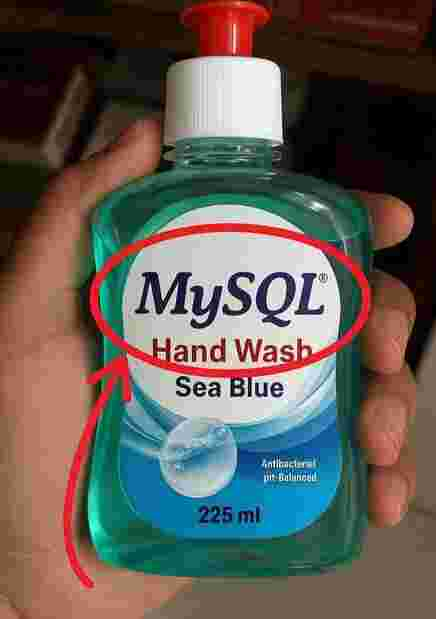



Instalación de los paquetes Python necesarios:

In [ ]:
import sys

RunningInCOLAB: bool = "google.colab" in sys.modules

In [ ]:
if RunningInCOLAB:
    !sudo apt-get update -qq
    !sudo apt-get install -y -qq mysql-server mysql-client
    !sudo service mysql start
    !sudo mysql -e "ALTER USER 'root'@'localhost' IDENTIFIED WITH mysql_native_password BY 'root'"

In [ ]:
%pip install --upgrade -q sqlalchemy pymysql cryptography 'pandas[performance,parquet,plot,output-formatting]' 'git+https://github.com/dsevilla/jupysql'

Cargamos la extensión SQL que permite ejecutar consultas SQL en celdas de Jupyter Notebook y obtener el resultado en un DataFrame de pandas. Esto se puede hacer gracias al paquete `jupysql`.

In [ ]:
%load_ext sql
%config SqlMagic.autopandas=True
%config SqlMagic.displaycon=False
%config SqlMagic.named_parameters="enabled"

In [ ]:
import matplotlib
import pandas as pd

%matplotlib inline
matplotlib.style.use("ggplot")

In [ ]:
import os

db_hostname: str = "localhost" if RunningInCOLAB else os.getenv("DB_HOSTNAME", "localhost")

In [ ]:
DATABASE_URL: str = (
    f"mysql+pymysql://root:root@{db_hostname}/?charset=utf8mb4&collation=utf8mb4_bin"
)

In [ ]:
%env DATABASE_URL=$DATABASE_URL

In [ ]:
from sqlalchemy import Engine, create_engine

engine: Engine = create_engine(DATABASE_URL, isolation_level="READ COMMITTED")

In [ ]:
%%sql engine
-- Configuración de la base de datos.
SET GLOBAL innodb_redo_log_capacity = 1000 * 1024 * 1024;
SET NAMES utf8mb4 COLLATE utf8mb4_bin;

In [ ]:
%%sql
DROP DATABASE IF EXISTS stackoverflow;
CREATE DATABASE stackoverflow;

In [ ]:
%%sql
USE stackoverflow;

<details><summary><b>🗂️ Formato datos Stackoverflow</b> <span style="color: #007acc;">▶️ Haz click para ver el esquema completo</span></summary>

 - Format: 7zipped
 - Files:
   - **badges**.xml
       - UserId, e.g.: "420"
       - Name, e.g.: "Teacher"
       - Date, e.g.: "2008-09-15T08:55:03.923"
   - **comments**.xml
       - Id
       - PostId
       - Score
       - Text, e.g.: "@Stu Thompson: Seems possible to me - why not try it?"
       - CreationDate, e.g.:"2008-09-06T08:07:10.730"
       - UserId
   - **posts**.xml
       - Id
       - PostTypeId
          - 1: Question
          - 2: Answer
       - ParentID (only present if PostTypeId is 2)
       - AcceptedAnswerId (only present if PostTypeId is 1)
       - CreationDate
       - Score
       - ViewCount
       - Body
       - OwnerUserId
       - LastEditorUserId
       - LastEditorDisplayName="Jeff Atwood"
       - LastEditDate="2009-03-05T22:28:34.823"
       - LastActivityDate="2009-03-11T12:51:01.480"
       - CommunityOwnedDate="2009-03-11T12:51:01.480"
       - ClosedDate="2009-03-11T12:51:01.480"
       - Title=
       - Tags=
       - AnswerCount
       - CommentCount
       - FavoriteCount
   - **posthistory**.xml
       - Id
       - PostHistoryTypeId
            - 1: Initial Title - The first title a question is asked with.
            - 2: Initial Body - The first raw body text a post is submitted with.
            - 3: Initial Tags - The first tags a question is asked with.
            - 4: Edit Title - A question's title has been changed.
            - 5: Edit Body - A post's body has been changed, the raw text is stored here as markdown.
            - 6: Edit Tags - A question's tags have been changed.
            - 7: Rollback Title - A question's title has reverted to a previous version.
            - 8: Rollback Body - A post's body has reverted to a previous version - the raw text is stored here.
            - 9: Rollback Tags - A question's tags have reverted to a previous version.
            - 10: Post Closed - A post was voted to be closed.
            - 11: Post Reopened - A post was voted to be reopened.
            - 12: Post Deleted - A post was voted to be removed.
            - 13: Post Undeleted - A post was voted to be restored.
            - 14: Post Locked - A post was locked by a moderator.
            - 15: Post Unlocked - A post was unlocked by a moderator.
            - 16: Community Owned - A post has become community owned.
            - 17: Post Migrated - A post was migrated.
            - 18: Question Merged - A question has had another, deleted question merged into itself.
            - 19: Question Protected - A question was protected by a moderator
            - 20: Question Unprotected - A question was unprotected by a moderator
            - 21: Post Disassociated - An admin removes the OwnerUserId from a post.
            - 22: Question Unmerged - A previously merged question has had its answers and votes restored.
        - PostId
        - RevisionGUID: At times more than one type of history record can be recorded by a single action.  All of these will be grouped using the same RevisionGUID
        - CreationDate: "2009-03-05T22:28:34.823"
        - UserId
        - UserDisplayName: populated if a user has been removed and no longer referenced by user Id
        - Comment: This field will contain the comment made by the user who edited a post
        - Text: A raw version of the new value for a given revision
            - If PostHistoryTypeId = 10, 11, 12, 13, 14, or 15  this column will contain a JSON encoded string with all users who have voted for the PostHistoryTypeId
            - If PostHistoryTypeId = 17 this column will contain migration details of either "from <url>" or "to <url>"
        - CloseReasonId
            - 1: Exact Duplicate - This question covers exactly the same ground as earlier questions on this topic; its answers may be merged with another identical question.
            - 2: off-topic
            - 3: subjective
            - 4: not a real question
            - 7: too localized
   - **postlinks**.xml
     - Id
     - CreationDate
     - PostId
     - RelatedPostId
     - PostLinkTypeId
       - 1: Linked
       - 3: Duplicate
   - **users**.xml
     - Id
     - Reputation
     - CreationDate
     - DisplayName
     - EmailHash
     - LastAccessDate
     - WebsiteUrl
     - Location
     - Age
     - AboutMe
     - Views
     - UpVotes
     - DownVotes
   - **votes**.xml
     - Id
     - PostId
     - VoteTypeId
        - ` 1`: AcceptedByOriginator
        - ` 2`: UpMod
        - ` 3`: DownMod
        - ` 4`: Offensive
        - ` 5`: Favorite - if VoteTypeId = 5 UserId will be populated
        - ` 6`: Close
        - ` 7`: Reopen
        - ` 8`: BountyStart
        - ` 9`: BountyClose
        - `10`: Deletion
        - `11`: Undeletion
        - `12`: Spam
        - `13`: InformModerator
     - CreationDate
     - UserId (only for VoteTypeId 5)
     - BountyAmount (only for VoteTypeId 9)

</details>

Definimos una función para leer el esquema de cada conjunto de datos. Lo describimos anteriormente como un esquema PyArrow.


In [ ]:
import io

import pyarrow as pa
import requests
from pyarrow import Schema


def read_remote_parquet_schema(url: str) -> Schema:
    """
    Downloads a remote Parquet file and returns its PyArrow schema.
    Args:
        url (str): The URL to the Parquet file.
    Returns:
        pyarrow.Schema: The schema of the Parquet file.
    """
    response: requests.Response = requests.get(url)
    response.raise_for_status()
    buffer = io.BytesIO(response.content)
    return pa.ipc.read_schema(buffer)

In [ ]:
from asyncio import Queue, Task, create_task, to_thread

# Start async tasks to fetch schemas in parallel
BASE_URL: str = "https://github.com/dsevilla/bd2-data/raw/refs/heads/main/es.stackoverflow/parquet"

posts_schema: Task[pa.Schema] = create_task(
    to_thread(read_remote_parquet_schema, f"{BASE_URL}/Posts.pb")
)
users_schema: Task[pa.Schema] = create_task(
    to_thread(read_remote_parquet_schema, f"{BASE_URL}/Users.pb")
)
tags_schema: Task[pa.Schema] = create_task(
    to_thread(read_remote_parquet_schema, f"{BASE_URL}/Tags.pb")
)
comments_schema: Task[pa.Schema] = create_task(
    to_thread(read_remote_parquet_schema, f"{BASE_URL}/Comments.pb")
)
votes_schema: Task[pa.Schema] = create_task(
    to_thread(read_remote_parquet_schema, f"{BASE_URL}/Votes.pb")
)

In [ ]:
def gen_create_table_from_schema(schema: pa.Schema, table_name: str) -> str:
    """
    Generate a CREATE TABLE SQL statement from a PyArrow schema.

    Args:
        schema: PyArrow schema
        table_name: Name for the SQL table

    Returns:
        SQL CREATE TABLE statement as string

    Metadata support:
        - 'primary_key': 'true' - marks column as primary key
        - 'foreign_key': 'Table.Attribute' - creates foreign key reference
    """
    # PyArrow to SQL type mapping
    type_mapping: dict[pa.DataType, str] = {
        pa.int8(): "TINYINT",
        pa.int16(): "SMALLINT",
        pa.int32(): "INTEGER",
        pa.int64(): "BIGINT",
        pa.uint8(): "TINYINT UNSIGNED",
        pa.uint16(): "SMALLINT UNSIGNED",
        pa.uint32(): "INTEGER UNSIGNED",
        pa.uint64(): "BIGINT UNSIGNED",
        pa.float32(): "REAL",
        pa.float64(): "DOUBLE",
        pa.bool_(): "BOOLEAN",
        pa.string(): "TEXT",
        pa.large_string(): "TEXT",
        pa.binary(): "BLOB",
        pa.large_binary(): "BLOB",
    }

    def get_sql_type(pa_type: pa.DataType) -> str:
        # Handle dictionary types by recursively processing the value type
        if pa.types.is_dictionary(pa_type):
            return get_sql_type(pa_type.value_type)
        elif pa.types.is_timestamp(pa_type):
            return "TIMESTAMP"
        elif pa.types.is_date(pa_type):
            return "DATE"
        elif pa.types.is_time(pa_type):
            return "TIME"
        elif pa.types.is_decimal(pa_type):
            return f"DECIMAL({pa_type.precision},{pa_type.scale})"
        elif pa.types.is_string(pa_type) or pa.types.is_large_string(pa_type):
            return "TEXT"
        # Direct mapping lookup
        return type_mapping.get(pa_type, "TEXT")

    # Helper to build DEFAULT clause
    def build_default_clause(fld: pa.Field) -> str:
        """Return the SQL DEFAULT clause (including leading space) for a field or
        an empty string when no default is present or it cannot be parsed.

        Args:
            fld: pyarrow Field instance

        Returns:
            A string like " DEFAULT 0" or " DEFAULT 'abc'" or empty string.
        """

        if not (fld.metadata and b"default" in fld.metadata):
            return ""

        default_val = fld.metadata[b"default"]
        try:
            # Integer types: treat binary 0 as 0
            if pa.types.is_integer(fld.type) or pa.types.is_unsigned_integer(fld.type):
                return f" DEFAULT {int(default_val.decode('utf-8'))}"
            elif pa.types.is_floating(fld.type):
                return f" DEFAULT {float(default_val.decode('utf-8'))}"
            elif pa.types.is_boolean(fld.type):
                sval = default_val.decode("utf-8").lower()
                return " DEFAULT 1" if sval in ("1", "true", "yes") else " DEFAULT 0"
            else:
                # treat as string-like
                sval = default_val.decode("utf-8")
                # escape single quotes
                sval = sval.replace("'", "''")
                return f" DEFAULT '{sval}'"
        except Exception:
            # fallback: ignore default on error
            return ""

    # Generate column definitions
    columns: list[str] = []
    primary_keys: list[str] = []
    foreign_keys: list[str] = []

    for field in schema:
        col_name: str = field.name
        sql_type: str = get_sql_type(field.type)

        # Check for nullable
        null_constraint: str = "" if field.nullable else " NOT NULL"

        # Build default clause using helper
        default_clause = build_default_clause(field)

        column_def: str = f"`{col_name}` {sql_type}{null_constraint}{default_clause}"
        columns.append(column_def)

        # Check metadata for primary key
        if field.metadata and b"primary key" in field.metadata:
            if field.metadata[b"primary key"] == b"true":
                primary_keys.append(col_name)

        # Check metadata for foreign key
        if field.metadata and b"foreign key" in field.metadata:
            ref_table_col: str = field.metadata[b"foreign key"].decode("utf-8")
            # Convert Table.Attribute to Table(Attribute)
            if "." in ref_table_col:
                table, attr = ref_table_col.split(".", 1)
                ref_table_col_sql = f"{table}({attr})"
            else:
                ref_table_col_sql = ref_table_col
            foreign_keys.append(f"FOREIGN KEY (`{col_name}`) REFERENCES {ref_table_col_sql}")

    # Build the CREATE TABLE statement
    create_parts: list[str] = [f"CREATE TABLE `{table_name}` ("]
    create_parts.append("    " + ",\n    ".join(columns))

    # Add primary key constraint
    if primary_keys:
        pk_cols: str = ", ".join(f"`{pk}`" for pk in primary_keys)
        create_parts.append(f",\n    PRIMARY KEY ({pk_cols})")

    # Add foreign key constraints
    if foreign_keys:
        for fk in foreign_keys:
            create_parts.append(f",\n    {fk}")

    create_parts.append(");")

    return "\n".join(create_parts)

## Importación de los datos

Eliminar temporalmente la comprobación de la consistencia de claves ajenas. Esto se hace por varias razones:

1. Para permitir la eliminación o modificación de registros en tablas que tienen claves foráneas sin que se produzcan errores de restricción.
2. Para facilitar la carga masiva de datos en tablas relacionadas sin tener que preocuparse por las restricciones de integridad referencial.
3. Para realizar operaciones de mantenimiento en la base de datos que pueden requerir la eliminación temporal de restricciones.

Es importante recordar que desactivar las comprobaciones de claves ajenas puede llevar a inconsistencias en los datos, por lo que se debe hacer con precaución y asegurarse de volver a habilitarlas una vez que se haya completado la operación necesaria.

In [ ]:
%%sql
SET GLOBAL foreign_key_checks = 0;

Empiezo la descarga de los ficheros parquet y preparamos el entorno para la ejecución de tareas en segundo plano.

In [ ]:
from asyncio import Task, create_task, to_thread

from pandas import DataFrame


def load_dataframe(
    tablename: str, parquet_files: str | list[str], logqueue: Queue | None = None
) -> bool:
    """
    Carga un DataFrame desde un archivo Parquet y lo inserta en una tabla de la base de datos.
    Si se especifica `logqueue`, se envían mensajes de log a la cola.

    Args:
        tablename (str): El nombre de la tabla en la base de datos.
        parquet_files (str | list[str]): El archivo Parquet o una lista de archivos Parquet a cargar.
        logqueue (Queue | None, optional): Una cola para registrar mensajes de log. Defaults to None.

    Returns:
        bool: True si la carga fue exitosa, False en caso contrario.
    """

    # Si nos envían na lista, concatenamos los archivos
    match parquet_files:
        case str():
            df: DataFrame = pd.read_parquet(f"{BASE_URL}/{parquet_files}")
        case list():
            df: DataFrame = pd.concat(pd.read_parquet(f"{BASE_URL}/{f}") for f in parquet_files)
    logqueue.put_nowait(f"Loaded {len(df)} rows from {tablename} dataframe.") if logqueue else None

    try:
        result: int | None = df.to_sql(
            tablename,
            con=engine,
            if_exists="append",
            index=False,
            schema="stackoverflow",
            chunksize=1000,
            method="multi",
        )

        (
            logqueue.put_nowait(f"Loaded {tablename} Dataframe. Result: {result}.")
            if logqueue
            else None
        )

    except Exception as e:
        logqueue.put_nowait(f"Error loading {tablename} Dataframe: {e}.") if logqueue else None
        return False
    finally:
        del df
    return True

In [ ]:
users_schema_sql: str = gen_create_table_from_schema(await users_schema, "Users")

print(users_schema_sql)

In [ ]:
%%sql
{{users_schema_sql}}

In [ ]:
users_log_queue: Queue = Queue()
users_dataframe_task: Task[bool] = create_task(
    to_thread(load_dataframe, "Users", "Users.parquet", users_log_queue)
)

In [ ]:
posts_schema_sql: str = gen_create_table_from_schema(await posts_schema, "Posts")

print(posts_schema_sql)

In [ ]:
%%sql
{{posts_schema_sql}}

In [ ]:
posts_log_queue: Queue = Queue()
posts_dataframe_task: Task[bool] = create_task(
    to_thread(
        load_dataframe,
        "Posts",
        ["Posts1.parquet", "Posts2.parquet", "Posts3.parquet"],
        posts_log_queue,
    )
)

In [ ]:
tags_schema_sql: str = gen_create_table_from_schema(await tags_schema, "Tags")

print(tags_schema_sql)

In [ ]:
%%sql
{{tags_schema_sql}}

In [ ]:
tags_log_queue: Queue = Queue()
tags_dataframe_task: Task[bool] = create_task(
    to_thread(load_dataframe, "Tags", "Tags.parquet", tags_log_queue)
)

In [ ]:
comments_schema_sql: str = gen_create_table_from_schema(await comments_schema, "Comments")

print(comments_schema_sql)

In [ ]:
%%sql
{{comments_schema_sql}}

In [ ]:
comments_log_queue: Queue = Queue()
comments_dataframe_task: Task[bool] = create_task(
    to_thread(load_dataframe, "Comments", "Comments.parquet", comments_log_queue)
)

In [ ]:
# Esperar a que termine la tarea
await users_dataframe_task
while not users_log_queue.empty():
    print(users_log_queue.get_nowait())

In [ ]:
%%sql
DESCRIBE Users;

In [ ]:
%%sql
SELECT * FROM Users LIMIT 3;

In [ ]:
await tags_dataframe_task
while not tags_log_queue.empty():
    print(tags_log_queue.get_nowait())

In [ ]:
%%sql
select * from Tags limit 6;

In [ ]:
await posts_dataframe_task
while not posts_log_queue.empty():
    print(posts_log_queue.get_nowait())

In [ ]:
%%sql
select count(*) from Posts;

In [ ]:
%%sql
select Id,Title,CreationDate from Posts LIMIT 3;

In [ ]:
%%sql
DESCRIBE Posts;

In [ ]:
await comments_dataframe_task
while not comments_log_queue.empty():
    print(comments_log_queue.get_nowait())

In [ ]:
%%sql
SELECT COUNT(*) FROM Comments;

In [ ]:
%%sql
SELECT * FROM Comments LIMIT 3;

In [ ]:
votes_schema_sql: str = gen_create_table_from_schema(await votes_schema, "Votes")

print(votes_schema_sql)

In [ ]:
%%sql
{{votes_schema_sql}}

In [ ]:
votes_log_queue: Queue = Queue()
votes_dataframe_task: Task[bool] = create_task(
    to_thread(load_dataframe, "Votes", "Votes.parquet", votes_log_queue)
)

In [ ]:
%%sql
EXPLAIN
SELECT Y.PostId,Y.Present
FROM (SELECT v.PostId AS PostId, COALESCE(p.Id,CONCAT('No: ', v.PostId)) AS Present
      FROM Votes v LEFT JOIN Posts p ON v.PostId = p.Id) AS Y
WHERE Y.Present LIKE 'No%';

In [ ]:
%%sql
EXPLAIN SELECT PostId from Votes WHERE PostId NOT IN (select Id from Posts);

In [ ]:
await votes_dataframe_task
while not votes_log_queue.empty():
    print(votes_log_queue.get_nowait())

In [ ]:
%%sql
select * from Votes LIMIT 20;

In [ ]:
%%sql
SELECT Y.Id, Y.PostId, Y.Present
FROM (SELECT v.PostId AS PostId, v.Id AS Id, p.Id AS Pid, COALESCE(p.Id, CONCAT('No: ', v.PostId)) AS Present
      FROM Votes v LEFT JOIN Posts p ON v.PostId = p.Id) AS Y
WHERE Y.Pid IS NULL
LIMIT 1000

### EJERCICIO: Eliminar de `Votes` las entradas que se refieran a Posts inexistentes

In [ ]:
%%sql --no-execute
-- DELETE FROM Votes WHERE ...

Ahora, vuelvo a reestablecer las comprobaciones de clave ajena porque después haremos un ejercicio relacionado.

In [ ]:
%%sql
SET GLOBAL foreign_key_checks = 1;

In [ ]:
%%sql --no-execute
-- Y ahora sí
ALTER TABLE Votes ADD FOREIGN KEY (PostId) REFERENCES Posts(Id),
                  ADD FOREIGN KEY (UserId) REFERENCES Users(Id);

In [ ]:
%%sql
SHOW TABLES;

In [ ]:
top_tags: DataFrame = get_ipython().run_line_magic(
    "sql", "SELECT Id, TagName, Count FROM Tags ORDER BY Count DESC LIMIT 40;"
)

¡¡Los resultados de `%sql` son un `DataFrame`!!

In [ ]:
# invert_y_axis() hace que el más usado aparezca primero. Por defecto es al revés.
top_tags.plot(kind="barh", x="TagName", y="Count", figsize=(14, 14 * 2 / 3)).invert_yaxis()

In [ ]:
top_tags

In [ ]:
%%sql
select Id,TagName,Count from Tags WHERE Count > 5 ORDER BY Count ASC LIMIT 40;

### EJERCICIO: Calcular las preguntas con más respuestas

En la casilla siguiente:

In [ ]:
%%sql
-- Preguntas con más respuestas (20 primeras)

In [ ]:
%%sql
select Title from Posts where Id = 5;

### Código de suma de posts de cada Tag

In [ ]:
# Calcular la suma de posts cada Tag de manera eficiente
import re

# Obtener los datos iniciales de los Tags
results: DataFrame = get_ipython().run_line_magic('sql', 'SELECT Id, Tags FROM Posts where Tags IS NOT NULL;')
tagcount: dict[str, int] = {}

for result in results.itertuples():
    # Inserta las tags en la tabla Tag
    tags: list[str] = re.findall('<(.*?)>', result[2])
    for tag in tags:
        tagcount[tag] = tagcount.get(tag, 0) + 1

# Comprobar que son iguales las cuentas
for k in tagcount.keys():
    res: DataFrame = get_ipython().run_line_magic('sql', 'SELECT TagName,Count FROM Tags WHERE TagName = :k;')
    if res.empty:
        print("Tag %s NO existe en la base de datos!!" % (k))
    elif tagcount[k] != res.iloc[0][1]:
        print("Tag %s NO coincide (%d)!!" % (k, res.iloc[0][1]))

In [ ]:
tagcount

In [ ]:
df = pd.DataFrame({"count": pd.Series(tagcount.values(), index=tagcount.keys())})
df

In [ ]:
sort_df: DataFrame = df.sort_values(by="count", ascending=False)

In [ ]:
sort_df

In [ ]:
sort_df[:100].plot(kind="bar", figsize=(20, 20 * 2 / 3))

In [ ]:
sort_df[-100:].plot(kind="bar", figsize=(20, 20 * 2 / 3))

## ¿Por qué usar un ORM (Mapeador Objeto-Relacional)?

Hasta ahora, hemos interactuado con la base de datos de dos maneras:
1.  Cargando datos masivamente desde ficheros Parquet.
2.  Ejecutando consultas SQL directamente para explorar y analizar los datos.

Ambos métodos son muy potentes, pero cuando empezamos a construir una aplicación más compleja sobre nuestros datos, escribir SQL para cada operación (crear, leer, actualizar, borrar) puede volverse repetitivo y propenso a errores, ya que hay que hacer un mapeo entre las abstracciones de la aplicación y las tablas, claves ajenas, etc.

Aquí es donde entra en juego un **ORM (Object-Relational Mapper)**, como [SQLAlchemy ORM](https://www.sqlalchemy.org/orm.html).

Un ORM es una capa de abstracción que "mapea" las tablas de nuestra base de datos relacional a objetos de Python. En lugar de escribir `SELECT * FROM Users WHERE ...`, trabajaremos con clases de Python como `User` y `Post`.

**Ventajas principales:**

- **Abstracción y Productividad**: Manipulamos objetos y sus atributos en Python, y el ORM se encarga de generar el SQL correspondiente. Esto agiliza el desarrollo y reduce el código repetitivo.
- **Código más "Pythónico"**: Nos permite pensar en términos de objetos, métodos y lógica de negocio, en lugar de la estructura de la base de datos.
- **Seguridad**: Los ORMs ayudan a prevenir ataques de inyección SQL, ya que parametrizan las consultas de forma segura.
- **Portabilidad**: Si en el futuro quisiéramos cambiar de MySQL a otro motor de base de datos (como PostgreSQL), el código de nuestra aplicación seguiría funcionando con mínimos cambios, ya que el ORM se adapta al "dialecto" SQL de cada motor.
- **Mantenimiento Sencillo**: El código es más legible y está mejor organizado, facilitando su mantenimiento a largo plazo.

En nuestro caso, vamos a definir las clases `User` y `Post` que se corresponderán con las tablas `Users` y `Posts` que ya hemos creado y poblado. Esto nos permitirá realizar operaciones sobre los datos de Stack Overflow de una manera mucho más intuitiva y orientada a objetos.

In [ ]:
from datetime import datetime
from typing import Optional

from sqlalchemy import (
    BigInteger,
    DateTime,
    ForeignKey,
    Integer,
    MetaData,
    Text,
)
from sqlalchemy.orm import Mapped, declarative_base, mapped_column, relationship

# Base class para todos los modelos ORM
# Apuntamos al esquema 'stackoverflow' que es donde están las tablas reales
metadata = MetaData(schema="stackoverflow")
Base = declarative_base(metadata=metadata)

Definimos como ejemplo las clases `User` y `Post` que representan las tablas `Users` y `Posts` respectivamente. Estas clases heredan de `Base`, que es la clase base para todos los modelos ORM en SQLAlchemy. Cada clase define sus atributos como columnas de la tabla correspondiente, utilizando el sistema de mapeo de SQLAlchemy.

Veremos cómo usar estas clases para realizar operaciones CRUD (Crear, Leer, Actualizar, Borrar) en la base de datos de una manera más intuitiva y orientada a objetos.

In [ ]:
class User(Base):
    __tablename__ = "Users"

    Id: Mapped[int] = mapped_column(BigInteger, primary_key=True)
    AboutMe: Mapped[str | None] = mapped_column(Text, nullable=True)
    AccountId: Mapped[int | None] = mapped_column(BigInteger, nullable=True)
    CreationDate: Mapped[datetime | None] = mapped_column(DateTime, nullable=True)
    DisplayName: Mapped[str | None] = mapped_column(Text, nullable=True)
    DownVotes: Mapped[int] = mapped_column(Integer, default=0)
    LastAccessDate: Mapped[datetime | None] = mapped_column(DateTime, nullable=True)
    Location: Mapped[str | None] = mapped_column(Text, nullable=True)
    Reputation: Mapped[int] = mapped_column(BigInteger, default=0)
    UpVotes: Mapped[int] = mapped_column(Integer, default=0)
    Views: Mapped[int] = mapped_column(BigInteger, default=0)
    WebsiteUrl: Mapped[str | None] = mapped_column(Text, nullable=True)

    # Relaciones: Un usuario puede ser autor o editor de muchos posts.
    # SQLAlchemy necesita saber qué clave foránea usar para cada relación.
    posts: Mapped[list["Post"]] = relationship(
        "Post", back_populates="owner", foreign_keys="Post.OwnerUserId"
    )
    edited_posts: Mapped[list["Post"]] = relationship(
        "Post", back_populates="last_editor", foreign_keys="Post.LastEditorUserId"
    )

    def __repr__(self) -> str:
        """Representación legible del objeto User."""
        return (
            f"<User(Id={self.Id}, "
            f"DisplayName='{self.DisplayName}', "
            f"Reputation={self.Reputation}, "
            f"Location='{self.Location}')>"
        )


class Post(Base):
    __tablename__ = "Posts"

    Id: Mapped[int] = mapped_column(BigInteger, primary_key=True)
    AcceptedAnswerId: Mapped[int | None] = mapped_column(ForeignKey("Posts.Id"), nullable=True)
    AnswerCount: Mapped[int | None] = mapped_column(Integer, default=0)
    Body: Mapped[str | None] = mapped_column(Text, nullable=True)
    ClosedDate: Mapped[datetime | None] = mapped_column(DateTime, nullable=True)
    CommentCount: Mapped[int | None] = mapped_column(Integer, default=0)
    CommunityOwnedDate: Mapped[datetime | None] = mapped_column(DateTime, nullable=True)
    ContentLicense: Mapped[str | None] = mapped_column(Text, nullable=True)
    CreationDate: Mapped[datetime | None] = mapped_column(DateTime, nullable=True)
    FavoriteCount: Mapped[int | None] = mapped_column(Integer, default=0)
    LastActivityDate: Mapped[datetime | None] = mapped_column(DateTime, nullable=True)
    LastEditDate: Mapped[datetime | None] = mapped_column(DateTime, nullable=True)
    LastEditorDisplayName: Mapped[str | None] = mapped_column(Text, nullable=True)
    LastEditorUserId: Mapped[int | None] = mapped_column(ForeignKey("Users.Id"), nullable=True)
    OwnerDisplayName: Mapped[str | None] = mapped_column(Text, nullable=True)
    OwnerUserId: Mapped[int | None] = mapped_column(ForeignKey("Users.Id"), nullable=True)
    ParentId: Mapped[int | None] = mapped_column(ForeignKey("Posts.Id"), nullable=True)
    PostTypeId: Mapped[int] = mapped_column(BigInteger)
    Score: Mapped[int] = mapped_column(Integer, default=0)
    Tags: Mapped[str | None] = mapped_column(Text, nullable=True)
    Title: Mapped[str | None] = mapped_column(Text, nullable=True)
    ViewCount: Mapped[int | None] = mapped_column(BigInteger, default=0)

    # Relación con el propietario (User) y el último editor (User)
    owner: Mapped[User | None] = relationship(
        "User", back_populates="posts", foreign_keys=[OwnerUserId]
    )
    last_editor: Mapped[User | None] = relationship(
        "User", back_populates="edited_posts", foreign_keys=[LastEditorUserId]
    )

    # Relaciones de un Post consigo mismo
    # Una pregunta (parent) tiene muchas respuestas (answers) - usa ParentId
    parent_post: Mapped[Optional["Post"]] = relationship(
        "Post", remote_side=[Id], foreign_keys=[ParentId], back_populates="answers"
    )
    answers: Mapped[list["Post"]] = relationship(
        "Post", foreign_keys=[ParentId], back_populates="parent_post"
    )

    # Una pregunta puede tener una respuesta aceptada - usa AcceptedAnswerId
    accepted_answer: Mapped[Optional["Post"]] = relationship(
        "Post", remote_side=[Id], foreign_keys=[AcceptedAnswerId], uselist=False
    )

    def __repr__(self) -> str:
        """Representación legible del objeto Post."""
        # Truncar el título y el cuerpo si son muy largos
        title_preview: str | None = (
            (self.Title[:50] + "...") if self.Title and len(self.Title) > 50 else self.Title
        )
        body_preview: str | None = (
            (self.Body[:80] + "...") if self.Body and len(self.Body) > 80 else self.Body
        )

        return (
            f"<Post(Id={self.Id}, "
            f"PostTypeId={self.PostTypeId}, "
            f"Title='{title_preview}', "
            f"Body='{body_preview}', "
            f"Score={self.Score}, "
            f"OwnerUserId={self.OwnerUserId})>"
        )

Si hubiera que crear desde cero las tablas `Users` y `Posts`, el ORM también podría encargarse de generar las sentencias SQL `CREATE TABLE` necesarias basándose en la definición de las clases. Para ello se utiliza el método `Base.metadata.create_all(engine)`.

In [ ]:
# Crear las tablas en la base de datos (si no existen) (No lo haremos, ya que las tablas ya existen)
# Base.metadata.create_all(engine)

Primero vemos un ejemplo de código para buscar un usuario en particular por su Id. Primero creamos la sesión.

In [ ]:
from sqlalchemy.orm import sessionmaker

# También mantener una sesión síncrona para compatibilidad
Session = sessionmaker(engine)

In [ ]:
with Session() as session:
    try:
        u: User = session.query(User).filter(User.Id == 5).one()
        print(u)
    except Exception as e:
        session.rollback()
        print(f"Error: {e}")
    finally:
        session.close()

In [ ]:
# Ejemplo: Obtener un Post y navegar al usuario propietario usando la relación `owner`
with Session() as session:
    try:
        # Recuperar un post concreto (por Id)
        post_id = 5
        post: Post | None = session.get(Post, post_id)
        if post is None:
            print(f"Post {post_id} no encontrado")
        else:
            # Acceder al owner (objeto User) a través de la relación ORM
            owner_user: User | None = post.owner
            if owner_user is None:
                print(f"Post {post_id} tiene OwnerUserId=None o el usuario no existe")
            else:
                print(
                    f"Post {post.Id} tit: {post.Title!r} pertenece a usuario: {owner_user.DisplayName!r} (id={owner_user.Id})."
                )
                # Podemos acceder a más campos del usuario
                print(f"Reputación: {owner_user.Reputation}, Location: {owner_user.Location}.")
                # También podemos navegar desde el usuario a sus posts (lista)
                print(
                    f"Número de posts que SQLAlchemy ha cargado en memoria para este usuario (relación): {len(owner_user.posts)}."
                )
    except Exception as e:
        session.rollback()
        print(f"Error: {e}")
    finally:
        session.close()

## EJERCICIOS
-----------------

### EJERCICIO: Crear una tabla "PostTags" que relaciona cada Tag con su Post

Tendrá cuatro entradas, Id, PostId (referencia a Posts.Id), TagId (referencia a Tags.Id) y TagName (nombre del tag copiado de Tags). Muestra cómo obtener los tags de un post y cómo ver todos los posts que se refieren a un tag.

### EJERCICIO: Para cada usuario calculad ratio (Accepted answers / total answers), mostrar top‑20 con suficiente volumen (al menos 10 respuestas)

Solución dada por la IA. ¿Qué falla?

In [ ]:
%%sql output <<
SELECT
    u.DisplayName,
    u.Id as UserId,
    COUNT(p.Id) as TotalAnswers,
    COUNT(accepted_q.AcceptedAnswerId) as AcceptedAnswers,
    ROUND(COUNT(accepted_q.AcceptedAnswerId) / COUNT(p.Id), 4) as AcceptanceRatio
FROM Users u
JOIN Posts p ON u.Id = p.OwnerUserId
JOIN Posts accepted_q ON p.Id = accepted_q.AcceptedAnswerId
WHERE p.PostTypeId = 2
GROUP BY u.Id
HAVING TotalAnswers >= 10
ORDER BY AcceptanceRatio DESC, TotalAnswers DESC
LIMIT 100;

In [ ]:
output

### EJERCICIO: ¿Cómo se podría encontrar lo más rápido posible todos los Posts de un Tag en particular (dando el TagName)?

Se deben dar varias alternativas comparando la eficiencia de cada una. Se deben hacer pruebas de eficiencia.

### EJERCICIO: Obtener top‑20 de preguntas (PostTypeId=1) por AnswerCount, con número de respuestas, media y desviación típica del Score de sus respuestas